TASK 1 — MCP NEURON (AND + OR)

AND Gate Code

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
def MCP_Neurons_AND(X1, X2, T):
    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        summed_value = X1[i] + X2[i]
        if summed_value >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

Testing AND Gate

In [ ]:
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2

result_and = MCP_Neurons_AND(X1, X2, T)
print("Output of AND gate:", result_and)

Output of AND gate: [0, 0, 0, 1]


Testing OR Gate

In [ ]:
T = 1

result_or = MCP_Neurons_OR(X1, X2, T)
print("Output of OR gate:", result_or)

Output of OR gate: [0, 1, 1, 1]


TASK 2

Task 2: Perceptron Algorithm for 0 vs 1 Classification

In [ ]:
df_0_1 = pd.read_csv("/content/drive/MyDrive/Artificial Intelligence and Machine Learning 2026/mnist_0_and_1.csv")

X = df_0_1.drop(columns=["label"]).values
y = df_0_1["label"].values

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


Visualizing the Dataset

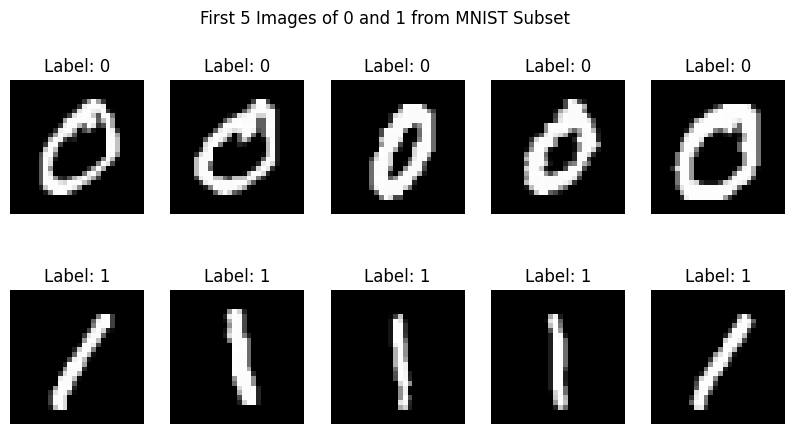

In [ ]:
images_0 = X[y == 0]
images_1 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")

        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")

    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

Initialization of Weights and Bias

In [ ]:
weights = np.zeros(X.shape[1])
bias = 0
learning_rate = 0.1
epochs = 100

print("Weights shape:", weights.shape)
print("Bias:", bias)

Weights shape: (784,)
Bias: 0


Decision Function / Activation Function

In [ ]:
def decision_function(X, weights, bias):
    predictions = np.dot(X, weights) + bias
    y_pred_all = np.where(predictions >= 0, 1, 0)
    return y_pred_all

Perceptron Learning Algorithm

In [ ]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    for epoch in range(epochs):
        correct = 0

        for i in range(len(X)):
            output = np.dot(X[i], weights) + bias
            y_pred = 1 if output >= 0 else 0

            if y_pred == y[i]:
                correct += 1
            else:
                weights = weights + learning_rate * (y[i] - y_pred) * X[i]
                bias = bias + learning_rate * (y[i] - y_pred)

        accuracy = correct / len(X)

    return weights, bias, accuracy

Training the Perceptron

In [ ]:
weights, bias, accuracy = train_perceptron(X, y, weights, bias, learning_rate, epochs)

print("The Final Accuracy is:", accuracy)

The Final Accuracy is: 1.0


Prediction on Entire Dataset

In [ ]:
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

Final Accuracy: 1.0000


Visualizing Misclassified Images

In [ ]:
misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")

    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

All images were correctly classified!


Loading 3 vs 5 Dataset

In [ ]:
df_3_5 = pd.read_csv("/content/drive/MyDrive/Artificial Intelligence and Machine Learning 2026/mnist_3_and_5.csv")

X_35 = df_3_5.drop(columns=["label"]).values
y_35 = df_3_5["label"].values

print("Feature matrix shape:", X_35.shape)
print("Label vector shape:", y_35.shape)

Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


Visualizing 3 and 5 Images

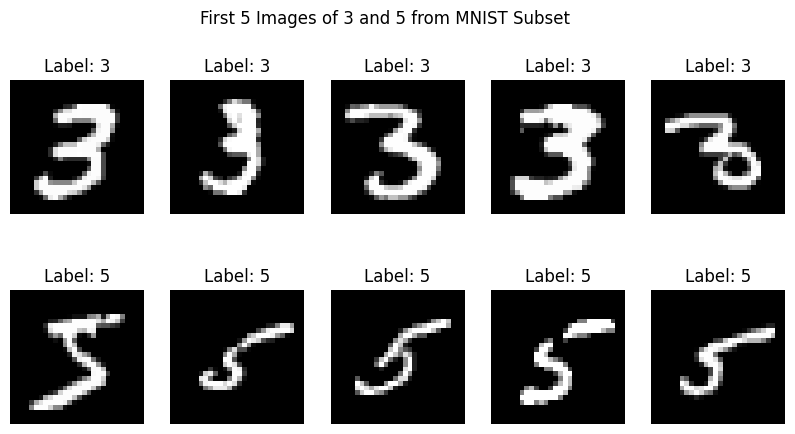

In [ ]:
images_3 = X_35[y_35 == 3]
images_5 = X_35[y_35 == 5]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_3) < 5 or len(images_5) < 5:
    print("Error: Not enough images to plot.")
else:
    for i in range(5):
        axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 3")
        axes[0, i].axis("off")

        axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 5")
        axes[1, i].axis("off")

    plt.suptitle("First 5 Images of 3 and 5 from MNIST Subset")
    plt.show()

Preparing Labels for Perceptron

In [ ]:
y_35_binary = np.where(y_35 == 5, 1, 0)

weights_35 = np.zeros(X_35.shape[1])
bias_35 = 0
learning_rate = 0.1
epochs = 100

Training Perceptron for 3 vs 5

In [ ]:
weights_35, bias_35, accuracy_35 = train_perceptron(
    X_35, y_35_binary, weights_35, bias_35, learning_rate, epochs
)

print("Final Accuracy for 3 vs 5:", accuracy_35)

Final Accuracy for 3 vs 5: 0.9857716161984678


Prediction and Accuracy for 3 vs 5

In [ ]:
predictions_35 = np.dot(X_35, weights_35) + bias_35
y_pred_35 = np.where(predictions_35 >= 0, 1, 0)

final_accuracy_35 = np.mean(y_pred_35 == y_35_binary)
print(f"Final Accuracy for 3 vs 5: {final_accuracy_35:.4f}")

Final Accuracy for 3 vs 5: 0.9869


Misclassified Images for 3 vs 5

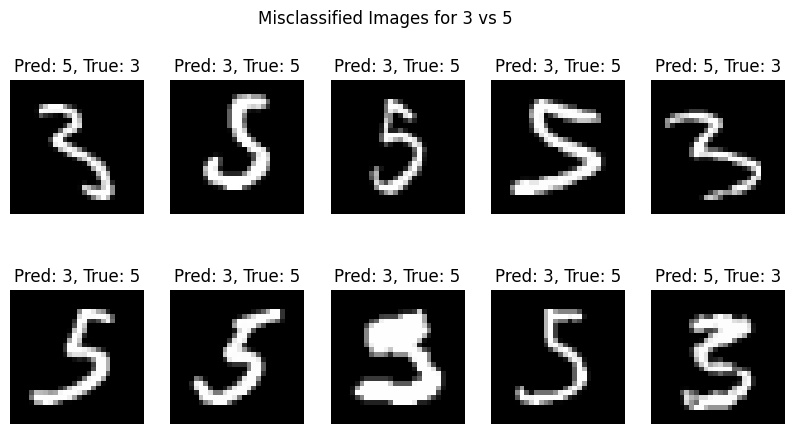

In [ ]:
misclassified_idx_35 = np.where(y_pred_35 != y_35_binary)[0]

if len(misclassified_idx_35) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx_35[:10]):
        ax.imshow(X_35[idx].reshape(28, 28), cmap="gray")
        pred_label = 5 if y_pred_35[idx] == 1 else 3
        true_label = 5 if y_35_binary[idx] == 1 else 3
        ax.set_title(f"Pred: {pred_label}, True: {true_label}")
        ax.axis("off")

    plt.suptitle("Misclassified Images for 3 vs 5")
    plt.show()
else:
    print("All images were correctly classified!")